In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('twitter_human_bots_dataset.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37438 entries, 0 to 37437
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     37438 non-null  int64  
 1   created_at                     37438 non-null  object 
 2   default_profile                37438 non-null  bool   
 3   default_profile_image          37438 non-null  bool   
 4   description                    30181 non-null  object 
 5   favourites_count               37438 non-null  int64  
 6   followers_count                37438 non-null  int64  
 7   friends_count                  37438 non-null  int64  
 8   geo_enabled                    37438 non-null  bool   
 9   id                             37438 non-null  int64  
 10  lang                           29481 non-null  object 
 11  location                       37434 non-null  object 
 12  profile_background_image_url   32939 non-null 

In [2]:
df.head()

,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,...,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type,profile_image_path,profile_background_image_path,split
0,0,2009-07-04 22:41:51,False,False,NaN,5007,102,168,False,53779179,...,https://pbs.twimg.com/profile_images/128969130...,paty_castroo,3974,False,0.978,4063,bot,NaN,NaN,0
1,1,2010-01-17 22:54:19,False,False,Television producer. Emmy Award winner. Disney...,1038,60,128,False,105916557,...,https://pbs.twimg.com/profile_images/632916759...,CBirckner,259,False,0.067,3866,human,profile_images/4691ae58668d932bb7e7af22141aecf...,profile_images/4691ae58668d932bb7e7af22141aecf...,0
2,2,2012-03-01 06:05:32,False,False,NaN,2257,599,449,True,509788597,...,https://pbs.twimg.com/profile_images/128853844...,amf_jay,13627,False,4.406,3093,human,NaN,NaN,0
3,3,2009-09-01 04:52:30,False,False,NaN,6407,116,334,True,70601327,...,https://pbs.twimg.com/profile_images/977012905...,SaraCavolo,4432,False,1.107,4005,human,profile_images/d1da9220e4aa376dff03b6f12765171...,profile_images/d1da9220e4aa376dff03b6f12765171...,0
4,4,2010-01-27 17:17:23,False,False,Productor de Televisión - Embajador de @Tienda...,20866,74448,18,True,108999927,...,https://pbs.twimg.com/profile_images/668449819...,DavidHenaoModel,15870,True,4.116,3856,human,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,0


In [3]:
print(df['account_type'].value_counts())

account_type
human    25013
bot      12425
Name: count, dtype: int64


In [4]:
#labele su bot i human, prebacicu ih u numericke bot==1 human == 0
df['label'] = (df['account_type'] == 'bot').astype(int)
df.head()

,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,...,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type,profile_image_path,profile_background_image_path,split,label
0,0,2009-07-04 22:41:51,False,False,NaN,5007,102,168,False,53779179,...,paty_castroo,3974,False,0.978,4063,bot,NaN,NaN,0,1
1,1,2010-01-17 22:54:19,False,False,Television producer. Emmy Award winner. Disney...,1038,60,128,False,105916557,...,CBirckner,259,False,0.067,3866,human,profile_images/4691ae58668d932bb7e7af22141aecf...,profile_images/4691ae58668d932bb7e7af22141aecf...,0,0
2,2,2012-03-01 06:05:32,False,False,NaN,2257,599,449,True,509788597,...,amf_jay,13627,False,4.406,3093,human,NaN,NaN,0,0
3,3,2009-09-01 04:52:30,False,False,NaN,6407,116,334,True,70601327,...,SaraCavolo,4432,False,1.107,4005,human,profile_images/d1da9220e4aa376dff03b6f12765171...,profile_images/d1da9220e4aa376dff03b6f12765171...,0,0
4,4,2010-01-27 17:17:23,False,False,Productor de Televisión - Embajador de @Tienda...,20866,74448,18,True,108999927,...,DavidHenaoModel,15870,True,4.116,3856,human,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,0,0


In [5]:
#Feature engineering
#Dodajem feature za opis profila
#I uzimam one koji vec postoje u datasetu
df['description_length'] = df['description'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['has_description'] = df['description'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1 )
df['has_location'] = df['location'].apply(lambda x: 0 if pd.isna(x) or str(x).strip().lower() in ['', 'unknown'] else 1)

features = [
    'followers_count',
    'friends_count',
    'favourites_count',
    'statuses_count',
    'average_tweets_per_day',
    'account_age_days',
    'description_length',
    'has_description',
    'has_location',
]

In [6]:
X = df[features].copy() #ulazni podaci ce biti feature-i koje sam izvukla iz dataseta, da se poklapaju sa onim koji cu koristiti posle za predikciju
y = df['label'].copy() #izlazna klasa da li je bot ili human

X = X.fillna(0)

print(X.shape)
print(X.head())

(37438, 9)
   followers_count  friends_count  favourites_count  statuses_count  \
0              102            168              5007            3974   
1               60            128              1038             259   
2              599            449              2257           13627   
3              116            334              6407            4432   
4            74448             18             20866           15870   

   average_tweets_per_day  account_age_days  description_length  \
0                   0.978              4063                   0   
1                   0.067              3866                  86   
2                   4.406              3093                   0   
3                   1.107              4005                   0   
4                   4.116              3856                 140   

   has_description  has_location  
0                0             1  
1                1             1  
2                0             0  
3                0 

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Test skup 15%
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

#Validacioni skup 15%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.176,  # 0.176 × 0.85 == 15% od pocetnog
    random_state=42, stratify=y_train_full
)

#Normalizacija
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}')
print(f'Val: {X_val_scaled.shape}')
print(f'Test: {X_test_scaled.shape}')

Train: (26221, 9)
Val:   (5601, 9)
Test:  (5616, 9)


In [15]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

print('Pre SMOTE: ',  y_train.value_counts().to_dict())
print('Posle SMOTE:', pd.Series(y_train_resampled).value_counts().to_dict())

Pre SMOTE:  {0: 17519, 1: 8702}
Posle SMOTE: {0: 17519, 1: 17519}


In [16]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train_resampled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_resampled, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [17]:
#TensorDataset i DataLoader

#DataLoader samo za train
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

#Validacioni DataLoader
val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [18]:
#Definisanje modela
import torch.nn as nn

class BotDetection(nn.Module):

  def __init__(self, input_dim):

    super().__init__()

    self.net = nn.Sequential(
        #linearna funkcija sa ulaznom dimenzijom (9 zbog 9 feature-a po profilu) i izlaznim brojem neurona
        nn.Linear(input_dim, 64),
        #posle svakog linear sloja ide aktivaciona fja da unese nelinearnost modelu
        nn.ReLU(),
        #nasumicno gasenje 30% neurona kako ne bi doslo do overfittinga
        nn.Dropout(0.3),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1),
        #poslednji sloj, primenjujemo funkciju koja dobijeni broj pretvara u verovatnocu 0-1, binarna klasifikacija == sigmoid
        nn.Sigmoid()
    )


  def forward(self, x):
    return self.net(x)

model = BotDetection(input_dim=X_train_scaled.shape[1])

print(model) #ispis arhitekture

BotDetection(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [28]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

#Earlz Stopping klasa
class EarlyStopping:

    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta

        self.best_loss = float("inf")
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
            torch.save(model.state_dict(), "best_model_early_stopping.pth")
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                print("Early stopping aktiviran.")

#Postavljanje modela, optimizacionog algoritma...
model = BotDetection(input_dim=X_train_scaled.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.BCELoss()
early_stopping = EarlyStopping(patience=10, delta=0.001)
num_epochs = 100

train_losses = []
val_losses = []

#Trening
for epoch in range(num_epochs):


    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    #validacija
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch_val, y_batch_val in val_loader:
            outputs = model(X_batch_val)
            loss = criterion(outputs, y_batch_val)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f'Epoha {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Patience: {early_stopping.no_improvement_count}/{early_stopping.patience}')

    early_stopping.check_early_stop(avg_val_loss, model)

    if early_stopping.stop_training:
        print(f'Trening zaustavljen u epohi {epoch+1}')
        break

# Ucitaj najbolji model
model.load_state_dict(torch.load('best_model_early_stopping.pth'))
print('Učitan najbolji model!')

Epoha 1/100 | Train Loss: 0.5634 | Val Loss: 0.4994 | Patience: 0/10
Epoha 2/100 | Train Loss: 0.5147 | Val Loss: 0.5053 | Patience: 0/10
Epoha 3/100 | Train Loss: 0.5008 | Val Loss: 0.5213 | Patience: 1/10
Epoha 4/100 | Train Loss: 0.4897 | Val Loss: 0.4776 | Patience: 2/10
Epoha 5/100 | Train Loss: 0.4852 | Val Loss: 0.4862 | Patience: 0/10
Epoha 6/100 | Train Loss: 0.4807 | Val Loss: 0.4937 | Patience: 1/10
Epoha 7/100 | Train Loss: 0.4782 | Val Loss: 0.4792 | Patience: 2/10
Epoha 8/100 | Train Loss: 0.4753 | Val Loss: 0.4811 | Patience: 3/10
Epoha 9/100 | Train Loss: 0.4754 | Val Loss: 0.4701 | Patience: 4/10
Epoha 10/100 | Train Loss: 0.4707 | Val Loss: 0.4578 | Patience: 0/10
Epoha 11/100 | Train Loss: 0.4669 | Val Loss: 0.4594 | Patience: 0/10
Epoha 12/100 | Train Loss: 0.4625 | Val Loss: 0.4672 | Patience: 1/10
Epoha 13/100 | Train Loss: 0.4605 | Val Loss: 0.4534 | Patience: 2/10
Epoha 14/100 | Train Loss: 0.4580 | Val Loss: 0.4609 | Patience: 0/10
Epoha 15/100 | Train Loss: 0.

              precision    recall  f1-score   support

       Human       0.88      0.81      0.84      3752
         Bot       0.67      0.78      0.72      1864

    accuracy                           0.80      5616
   macro avg       0.78      0.80      0.78      5616
weighted avg       0.81      0.80      0.80      5616

Tačnost modela: 0.8006
AUC-ROC: 0.8812142107900107


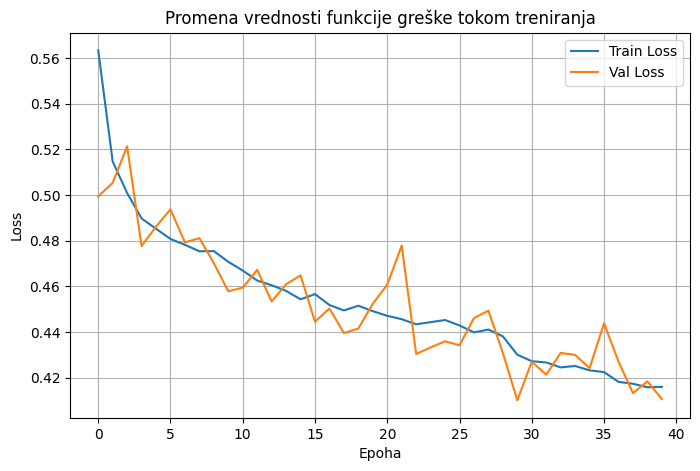

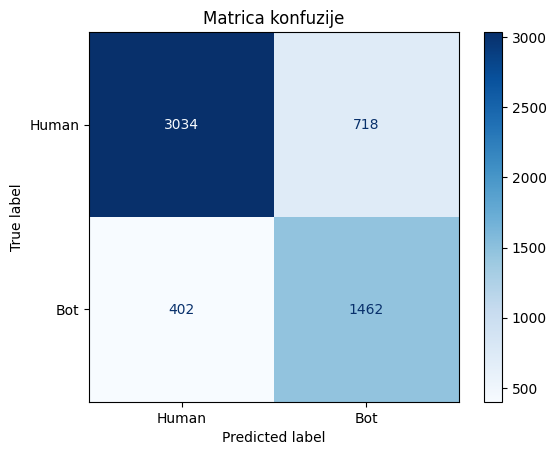

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred_prob = model(X_test_t).squeeze().numpy()

y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Human', 'Bot']))
accuracy = accuracy_score(y_test, y_pred)
print("Tačnost modela:", round(accuracy, 4))
print('AUC-ROC:', roc_auc_score(y_test, y_pred_prob))

# Loss funkcija
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoha')
plt.ylabel('Loss')
plt.title('Promena vrednosti funkcije greške tokom treniranja')
plt.legend()
plt.grid(True)
plt.show()

# Matrica konfuzije
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'Bot'])
disp.plot(cmap='Blues')
plt.title('Matrica konfuzije')
plt.show()

In [30]:
import pandas as pd
import torch
import joblib


pred_df = pd.read_csv('Tweeter_Data_IN.csv')

# Cvorovi iz jezgra novog dataseta
jezgro = {'JayNarwade', 'inaWay_', 'jashwantjazz', 'SANTHOSHAH3', 'PranavJayade',
           'prakalpa', 'DrIndian2', 'derekkandur', 'Atullal71', 'MdAleemshariff',
           'nsvirk', 'psk_eng', 'DrKumarSudhir', 'Satishrathod100', 'MUKESHR23927216',
           'mohitsaxena707', 'rakesh_jsl', 'niraj_t23', 'akjalanca', 'ITC_SaurabhP',
           'ssunyyyyyyyy', 'BhorkarNilesh', 'MayankM50873152', 'JivanPachpute',
           'BidishaSaha12', 'SakalMediaNews', 'SachinSNPandey', 'aneeshmuthyala',
           'nisargshah1489', 'sbtripathiadvoc', 'j123456789u', 'Rudra_82',
           'Rakeshs81787739', 'TaruniGandhi', 'rameshagarwal2', 'NANIPV',
           'drpankajkanwar', 'Gaura2000', 'DeepakK96530224', 'iVishwalok',
           'urdinesh', 'OmiAli5', '486Sanjay', 'minupuri_r', 'analvenerable',
           'BhattShaunak07', 'casteofcreators', 'Abhijit_biyani', 'Sumityadv4u',
           'sumiitksahani', 'AVNISHVASHISITA', 'deepak_mragwani', 'owaizafifa',
           'RoyNabojit', 'Sandeep698Yadav', 'drpreetiyadav9', 'chawla_paras',
           'Raviravirai', 'HemantPratap22', 'AJAYSHARMA1139', '10djfjj',
           'RomasaShukla', 'SrChandanMishra', 'swabhimansonu', 'rajtakke',
           'officialvish007', 'anildamani', 'riteshkarkera', 'SaurabhVShukla',
           'hope_india2014', 'theshubhamgour', 'SidharthaBajpai', 'ImRahulVyas1973',
           'AshBiswal', 'PPMishra18', 'KiranKumarKar3', 'sak8kumar', 'TanurajT',
           'breakruless', 'vidhibharatipar', 'gelesh_ramani', 'modassar43',
           'rajivgoyal', 'riteshgarg1061', 'MKC1_Reddy', 'MrshyamSinghan1',
           'SUBHASH60348539', 'budha1008', 'abhi795', 'sudipta9671287',
           'iamanilshetty', 'Prabhu4BJP', 'DibasKumarSahu', 'Dubeymkd1944',
           'thepiyussh', 'ankitrstg', 'MukundRanjan15', 'Santosh85719350',
           'BokadiyaShubham', 'Sanjays81301051', 'ssr99', 'Santosh88103354',
           'RajanKumarSri17', 'SADEVANTRM', 'bcbehere', 'aumnamah_',
           'tejasvi_ramesh', 'AshishaRajput', 'iamrajeevjha', 'Adv_RakeshSingh',
           'MrRaviRanjan05', 'Nitjan6', 'Amit_RedDevil', 'Nikhil4unik',
           'abhi_krishnatre', 'RAWSindia', 'Dharmin_Soni', 'Shivammsrshanta',
           'SanjuMishra731', 'manjunath_rbg', 'AJAYYAD84048995', 'bhoyarvishal5',
           'ravikant55', 'krispin1991', 'shobhit_05', 'UdageAmol', 'Rajpoot00Lokesh',
           'pkroy0077', 'PRADEIDO', 'MLMANDOWARA', 'Ashu_k_singh', 'chirag_686',
           'kmbhupender', 'akashtiwari9621', 'NamoAmitShukla', 'ArunabhHazarik1',
           'deldanladakhi', 'i_mangeshmhatre', '3783dinesh', 'KamleshbhaiPa10',
           'Ydjain123', 'SatyanarayanT17', 'srstavdheeraj', 'thanecitizens',
           'KARTHIC_VINOBA', 'NareshS69287229', 'DhanalaxmiKarn1', 'RajAsrondkar',
           'AjayGupta6774', 'PJJaiHind', 'Sandy0157385026', 'nik27896',
           'knmishra123', 'itskushalroy', 'rathirathi2001', 'balasubra9',
           'Rohtak_Kohinoor', 'manialmal', 'only_gurubhai', 'raomeenakshi7',
           'ayush_kacholiya', 'AMARNATHJHA', 'shobhitgupta528', 'bahl88',
           'sauravabc16', 'dhruvvvv7', 'heeraman98', 'iNikssoni', 'SibasisSatpathy',
           'mobile_dot', 'prabhat_neeraj', 'abhishek44spl', 'harshpatilp',
           'RajuMon43855976', 'ranjanas89', 'IndianMaverick', 'director_mohanr',
           'VKMishra2171984', 'PranabCBJP', 'sachinattri', 'Amaresh03335514',
           'm37256893', 'GreatScorpion1', 'harendrang8', 'HarshDaTaurian',
           'advocatesarin', 'AjayYadav2119', 'azhar046', 'meraki_says', 'mahi51142874',
           'amitabhnews18', 'jansevakind', 'advocatemj1', 'PraveenPratapS1',
           'varoonagrawal', 'RaghuDeva', 'Ranjeetgupta08', 'bhardwajdeepti3',
           'neercof', 'sonu_shah93', 'AtulGup17260129', 'PREMKUM14299724',
           'karthikdurai_t', 'abhi_singh2244', 'raj2jas', 'BhatiaonGround0',
           'agrawal_sugandh', 'AsifAli75497018', 'TEJASVPANCHAL1', 'ChittorArtFest',
           'TahaAnsari03', 'raj405789sd', 'rao_lk', 'DheerajSingh899', 'vinaygoyal65',
           'jaysureshnaidu', 'rdamodare', 'ksbjpchennai', 'rahul13roc',
           'BhavaneshBehere', 'KirenRijiju', 'agp_98', 'MonuJhumpa', 'KrArvi1',
           'Abhinav8341', 'chandanprajaptk', 'bgsubhash', 'sunita1210', 'VijayJollyBJP',
           'shabirhussain82', 'chhachhiyank', 'Samkt53', 'smdrao', 'raj0687',
           'pathaksamir', 'SushilMohanty1', 'idnani_nandini', 'Ganeshsahoo007',
           'AnilKhatana1990', 'apnathought', 'MIstiyaque', 'DineshS95469482',
           'shekh1959', 'amitmalpani75', 'VinayTiwariVT', 'MirpagarPrakash',
           'iamsinghprakash', 'priteshlhariya', 'SadhuStella', 'IamShoumikDas',
           'nitinshankar', 'rajkumar_1804', 'Shoshit_Banker', 'ashishbiltharia',
           'Kavita_M57', 'RohitYa75249166', 'Anuradha_Singh1', 'MdMdaun0007',
           'sufi_centre', 'alex_gaga1961', 'rupeshpreneur', 'RaghavJhaji',
           'drpatel2111', 'Fight_For_India', 'bRaHmASuJoK', 'RameshKumarKej4',
           'pareekindia', 'VirendraChowdh2', 'navaidhamid', 'nrshimla',
           'Yogi_Akhilesh_', 'pdkamath', 'SunilMalaji', 'natulbj2b', 'Himanshupati1',
           'CA_HEMANTRATHI', 'sailesh2000', 'er_harshbhavsar', 'Saurabh_Munger',
           'HKakriya', 'GroverGuneet', 'ChaurasiaSoumya', 'tejaswinimanogn',
           'Mohanch74268719', 'NationalistIn14', 'ashishsonde', 'AnuragKirti1',
           'Sudhi2803', 'Rkmalhotra12', 'KookeelD', 'pitambarp7', 'mishr_pramod',
           'colkt', 'KavendraSagar', 'kumarpramod815', 'ImkumarGulshan',
           'prabhakarhindu2', 'utsavmethi', 'zasambhu', 'manjur_khann', 'abhilash19_6',
           'kunjbihari1x', 'Divesh3786', 'ajay_kumar_i', 'amarkantca', 'sachin_singla',
           'VGtweets_', 'sunair10', 'rajeshbaniya', 'AshokPr08470555', 'ap_82',
           'mahajan1bhushan', 'gopalkagarwal', 'raghavendra16', 'AdityaT26742572',
           'JawaharLalMeh13', 'KotaNeelima', 'RajatKumarTiwa7', 'sudheerakki175',
           'ArvindB13274904', 'mohta_yash', 'Uttishta_Bharat', 'parveezjaleel',
           'spaceRupesh', 'VijayKapur17', 'sadahaqchief', 'sram_ji', 'sanjoodhariwal',
           'aamirk9892', 'VinodGi62575507', 'Sweety_kumari11', 'AmitAna56825393',
           'AshishS33851324', 'gunshot_rohit', 'dewangs', 'Sanjayk56382160',
           'sameerakapoor', 'linking_the', 'UmaShan15621203', 'akshrAj46', 'dharmu8194',
           'HitendraVora2', 'NarasimhaMyla', 'ashok_dwivedy', 'jainpri2003', 'lotusk3',
           'ravichandransun', 'ashish_s_baghel', 'PrasiddhiF', 'Rajkr5031', 'NashitNr',
           'apnaworldwide', 'imvijay_author', 'DR_DINESH_GUPTA', 'HemendraDr',
           'KumarSahitya2', 'Imgauravgupta_', 'aupadhyay16', 'Arunbha56270931',
           'AliKaashifKhan', 'AjaySha99657793', 'AjayVal87199332', 'anant1anand',
           'immiiAsh', 'patelravi127', 'ilesh_999', 'BinodmauryaG', 'Dishank_09',
           'ShubhankarKuma7', 'AR_RAVIKANT', 'TenNewsDotIn', 'hemalmodiusa',
           'Maddy88372127', 'anand_veecee', 'aripho', '3tarungupta', 'NamahaBharata',
           'kapilambaliya', 'Sam28763059', 'Dev58554643', 'DipenSadrani',
           'Krishna35901251', 'anandpgtkvs', 'NareshSaur', 'IamBunty_Shaikh',
           'realshwetaM', 'ronniesulli147', 'aniruddha_tiger', 'aksingh029',
           'ManishG80580092', 'subhashsagthiya', 'ramraje_shinde', 'RamRajendraMan1',
           'DrSWKorpeINC', 'BaagRafiuddin', 'drnitinchaube', 'MansoorKhanINC',
           'kartikey__singh', 'RakeshA12572734', 'begrajsharma', 'rj_varshaa',
           'Raghuvirsinh54', 'Rathore_Manani', 'sportsdoc4you', 'RathanRameshRR1',
           'gangodichandra', 'ImAnkitRajendra', 'jayashishpandey', 'MSAalamOfficial',
           'manoj_sdm', 'Helping36560414', 'VijendraBathija', 'HemrajUj', 'VipinKu_',
           'SinghSatyjeet', 'SMaharana89', '8527115900', 'bhardwajrakesh4',
           'Sandeepyadav04', 'shashank088', 'GULSHAN91538646', 'drreetusharma',
           'bhushan_UWH', 'Khatrihimansh27', 'neodalit', 'DrKapilKakar', 'Filter_work',
           'MeeraSh06468872', 'yashpsehgal', 'rpsinha393', 'SKG1953', 'rajaditya3',
           'im_sam007', 'IndrajitBairwa', 'Pulkit_Talks', 'ParveshSheoran4',
           'NewIndiaOff', 'MilestoneNgo', 'devanghexa', 'pafcoms', 'AmitSarathe01',
           'SudhirK05383417', 'RaviRamp36', 'abv_02', 'sasikp', 'DharmapuriPran1',
           'raghav_rishabh', 'TjayJugJagger', 'drnarayananraja', 'RahulGa46692878',
           'AbhishekTr', 'IMOHANALOK', 'sumantaghosh', 'dr_rajeevsharma',
           'priyagupta999', 'ashishjswl89', 'ersunilsaxena04', 'DATTAMASKARE1',
           'GandhiParthiv', 'ManishBajpaiBjp', 'SubhransuKumar3', 'SwapnilCM',
           'PRATAPB21838216', 'kmarkri', 'sahillateef7', 'sukantamishra',
           'ManumaneeshK', 'aamritanshuaman', 'kulkarnipiyush1', 'CommonM56559063',
           'Pa1Pavanreddy', 'atharvaindia', 'bbbehera52', 'Chepu13', 'varunmishra79',
           'WriterManisha', 'anilsoni2k', 'pranshu_tomar', 'gnkamat', 'CHANDERBHANVER1',
           'FilmDirSunil', 'KaustubhTri', 'kamleshmodi', 'Ravishashtrikum', 'guptab02',
           'GelotMohanlal', 'msakshi030', 'Shalini50251722', 'RajeshSBhadoria',
           'VjJeet', 'Rakeshsaroha19', 'neerajagr1', 'Prakash10149903', 'dc_gyan',
           'Kmr4Prince', 'garkalvijay', 'sezhiyan_m', 'lokesh_singh_', 'gsec_hbti',
           'NikitTandel', 'BhartiSahyog', 'Mayur1795', 'neerajsonu9995', 'kunal_daga',
           'AmitPal49', 'TBChronicle', 'hc_tripathi', 'hansrajmeena000', 'Real_Rohit98',
           'iTheUshabh', 'Chauhan_csk', 'Iamlokesh1510', 'rajfederer', 'SolankiVardaram',
           'VardhanChitresh', 'Kanhaiy32886799', 'nitishnonu4', 'pushp180', 'ossharma12',
           'avisek_c', 'KsnMurt73963068', 'mvapselvam', 'dchoudhary85',
           'baidyanathbhmct', 'BrindabanMukho3', 'Ramakan35236434', 'GGT_PATIL',
           'anishpandey1', 'scrapsona', 'maheshbaria', 'rajatsharmanks', 'gdc_111',
           'misanketmahadik', 'SameerGaikwad', 'KumarMeonly410', 'shri6385',
           'rajkumarmattu', 'AIRTUINDIA', 'tarun_bhuyan', 'GSubramaniam18',
           'abhinavkmishra', 'RohitDa29783574', 'sharvani67', 'harshit15295',
           'HaifIndia', 'PranjanRajmedhi', 'borana_borana', 'harddyharshvc',
           'AkmishraJsr', 'Bubai_12', 'only4insurance', 'pragatik', 'jatinder_vir',
           'shelar', 'manish_wahal', 'reddythirumal_a', 'KunalSarangi', 'CRajiva',
           'Rashmi_R89', 'prabhakar2707', 'Ervikram44Kumar', 'mrVinay_71',
           'badiger_rudresh', 'rohitcool_singh', 'Mmanish_Sspeaks', 'VvekTyagi',
           'pandeyrohit', 'Abhishek1seven', 'imakshaymalviya', 'Chintan51235861',
           'iamsunil44', 'saurabh23392', 'rajaryan12345', 'bhatanil1973',
           'PrabhuD41653306', 'Hardik_Nik', 'drvipin12', 'kabeer1510', 'iabhaypratap',
           'Deepak29_Jain', 'shwetaberry', 'ImRaina', 'daddy_dangi', 'viratpatil__',
           'raahat25236487', 'Arun_Srk24', 'SR_2789', 'Captaindksingh', 'shray4u',
           'priran', 'ashvindonda', 'vipan26garg', 'NaveenS01111630', 'Santosh38764186',
           'Mrsiddhartomar', 'VivekSharma_SNS', 'vivekGhanekar7', 'pradeepkb28',
           'karthik_b87', 'Shivani90923419'}


pred_filtered = pred_df[pred_df['user_screen_name'].isin(jezgro)].copy()
print(f'Ukupno tvitova u jezgru: {pred_filtered.shape[0]}')
print(f'Ukupno korisnika u jezgru: {pred_filtered["user_screen_name"].nunique()}')

# spajanje svih informacija po korisniku
pred_users = pred_filtered.groupby('user_screen_name').agg({
    'user_followers_count':  'first',
    'user_friends_count':    'first',
    'user_favourites_count': 'first',
    'user_statuses_count':   'first',
    'user_description':      'first',
    'user_location':         'first',
}).reset_index()

print(f'Broj korisnika nakon spajanja: {pred_users.shape[0]}')

Ukupno tvitova u jezgru: 3621
Ukupno korisnika u jezgru: 600
Broj korisnika nakon spajanja: 600


In [31]:
# Feature-i
pred_users['description_length'] = pred_users['user_description'].apply(
    lambda x: len(str(x)) if pd.notna(x) else 0
)
pred_users['has_description'] = pred_users['user_description'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1
)
pred_users['has_location'] = pred_users['user_location'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip().lower() in ['', 'unknown'] else 1
)

# mapiranje naziva kolona
pred_users = pred_users.rename(columns={
    'user_followers_count':  'followers_count',
    'user_friends_count':    'friends_count',
    'user_favourites_count': 'favourites_count',
    'user_statuses_count':   'statuses_count',
})


#Kolone kojih nema u novom datasetu
# account_age_days — uzmi datum prvog tvita kao primer
reference_date = pd.to_datetime('2020-04-14').tz_localize('UTC')

first_tweet = pred_filtered.groupby('user_screen_name')['created_at'].min()
first_tweet = pd.to_datetime(first_tweet, utc=True)

pred_users['account_age_days'] = pred_users['user_screen_name'].map(
    lambda u: (reference_date - first_tweet[u]).days if u in first_tweet else 0
)

# average_tweets_per_day — broj tvitova / broj dana aktivnosti
tweet_counts = pred_filtered.groupby('user_screen_name').size()
pred_users['average_tweets_per_day'] = pred_users['user_screen_name'].map(
    lambda u: tweet_counts.get(u, 0) / max(pred_users.loc[
        pred_users['user_screen_name'] == u, 'account_age_days'
    ].values[0], 1)
)



features = [
    'followers_count',
    'friends_count',
    'favourites_count',
    'statuses_count',
    'average_tweets_per_day',
    'account_age_days',
    'description_length',
    'has_description',
    'has_location',
]

/tmp/ipykernel_820/1023995210.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  first_tweet = pd.to_datetime(first_tweet, utc=True)


In [32]:
X_pred = pred_users[features].fillna(0)

# scaler
X_pred_scaled = scaler.transform(X_pred)
X_pred_t = torch.tensor(X_pred_scaled, dtype=torch.float32)

In [33]:
# predikcija
model.eval()
with torch.no_grad():
    pred_probs = model(X_pred_t).squeeze().numpy()

pred_users['bot_probability']   = pred_probs
pred_users['predicted_label']   = (pred_probs > 0.5).astype(int)
pred_users['predicted_account'] = pred_users['predicted_label'].map(
    {0: 'human', 1: 'bot'}
)

In [34]:
# rezultati

print(pred_users['predicted_account'].value_counts())

print('\n 10 najverovatnijih botova')
print(pred_users[['user_screen_name', 'bot_probability', 'predicted_account']]
      .sort_values('bot_probability', ascending=False)
      .head(10).to_string())

print('\n 10 najverovatnijih humana')
print(pred_users[['user_screen_name', 'bot_probability', 'predicted_account']]
      .sort_values('bot_probability', ascending=True)
      .head(10).to_string())

# cuvanje rezultata
pred_users[['user_screen_name', 'bot_probability', 'predicted_account']].to_csv(
    'predictions_jezgro.csv', index=False
)

predicted_account
human    518
bot       82
Name: count, dtype: int64

 10 najverovatnijih botova
    user_screen_name  bot_probability predicted_account
506   raahat25236487         0.978625               bot
266   SushilMohanty1         0.958896               bot
481   only4insurance         0.941202               bot
315    amitabhnews18         0.939691               bot
514    rajaryan12345         0.926576               bot
329    apnaworldwide         0.921676               bot
283     VijayKapur17         0.912663               bot
92         Gaura2000         0.910531               bot
269      TBChronicle         0.885465               bot
368     dchoudhary85         0.857991               bot

 10 najverovatnijih humana
    user_screen_name  bot_probability predicted_account
392    gopalkagarwal         0.027038             human
113          ImRaina         0.031120             human
159   MrRaviRanjan05         0.047287             human
258    SinghSatyjeet         0.051